# Analysing data

## Numpy

We will analyse patient data using a library called `numpy`. We can think of a library as specialised functions, different from the built-in functions we saw earlier. We will first **import** the library, then **load** the data 

In [1]:
import numpy

In [2]:
numpy.loadtxt(fname='data/inflammation-01.csv', delimiter=',')

array([[0., 0., 1., ..., 3., 0., 0.],
       [0., 1., 2., ..., 1., 0., 1.],
       [0., 1., 1., ..., 2., 1., 1.],
       ...,
       [0., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 2., 0.],
       [0., 0., 1., ..., 1., 1., 0.]])

So far, we loaded the data but we should save it into a variable to use it later. For example, we can print it.

In [3]:
data = numpy.loadtxt(fname='data/inflammation-01.csv', delimiter=',')
print(data)
print(type(data))

[[0. 0. 1. ... 3. 0. 0.]
 [0. 1. 2. ... 1. 0. 1.]
 [0. 1. 1. ... 2. 1. 1.]
 ...
 [0. 1. 1. ... 1. 1. 1.]
 [0. 0. 0. ... 0. 2. 0.]
 [0. 0. 1. ... 1. 1. 0.]]
<class 'numpy.ndarray'>


As mentioned earlier, libraries have specialised functions. `numpy` has functions to explore data. For example `shape`

In [4]:
print(data.shape)

(60, 40)


`shape` indicates `data` has 60 rows and 40 columns. The **type** of `data` is **array**. Arrays can be accessed by "0-based" indexes

In [5]:
print('first value in data:', data[0, 0])
print('last value in data:',  data[59, 39])

first value in data: 0.0
last value in data: 0.0


We can also **slice** arrays, meaning we can select parts of the data by using indexes

In [6]:
# slice the first 4 rows and the first 10 columns
print(data[0:4, 0:10])

[[0. 0. 1. 3. 1. 2. 4. 7. 8. 3.]
 [0. 1. 2. 1. 2. 1. 3. 2. 2. 6.]
 [0. 1. 1. 3. 3. 2. 6. 2. 5. 9.]
 [0. 0. 2. 0. 4. 2. 2. 1. 6. 7.]]


In [7]:
# slice rows 5 to 10 and the first 10 columns
print(data[5:10, 0:10])

[[0. 0. 1. 2. 2. 4. 2. 1. 6. 4.]
 [0. 0. 2. 2. 4. 2. 2. 5. 5. 8.]
 [0. 0. 1. 2. 3. 1. 2. 3. 5. 3.]
 [0. 0. 0. 3. 1. 5. 6. 5. 5. 8.]
 [0. 1. 1. 2. 1. 3. 5. 3. 5. 8.]]


We can also save slices into variables and use functions on them

In [8]:
small = data[:3, 36:]
print('small is:')
print(small)

small is:
[[2. 3. 0. 0.]
 [1. 1. 0. 1.]
 [2. 2. 1. 1.]]


We can also do descriptive statistics using `numpy` functions. Let's calculate the *mean* of our `data`

In [9]:
print(numpy.mean(data))

6.14875


Let's get more descriptions using multiple assignments to get all in one go

In [10]:
maxval, minval, stdval = numpy.amax(data), numpy.amin(data), numpy.std(data)

print('maximum inflammation:', maxval)
print('minimum inflammation:', minval)
print('standard deviation:', stdval)

maximum inflammation: 20.0
minimum inflammation: 0.0
standard deviation: 4.613833197118566


In our dataset, each *row* represents a *patient* and each *column* holds the inflammation value per *day*. We can use *slices* to obtain patient-specific data

In [11]:
patient_0 = data[0, :] # 0 on the first axis (rows), everything on the second (columns)
print('maximum inflammation for patient 0:', numpy.amax(patient_0))
print('maximum inflammation for patient 2:', numpy.amax(data[2, :]))

maximum inflammation for patient 0: 18.0
maximum inflammation for patient 2: 19.0


We can use *axes* to do operations on rows (axis 0), and on columns (axis 1)

In [12]:
# mean inflammation per patient (rows, axis 0)
print(numpy.mean(data, axis=0))
print(numpy.mean(data, axis=0).shape)

[ 0.          0.45        1.11666667  1.75        2.43333333  3.15
  3.8         3.88333333  5.23333333  5.51666667  5.95        5.9
  8.35        7.73333333  8.36666667  9.5         9.58333333 10.63333333
 11.56666667 12.35       13.25       11.96666667 11.03333333 10.16666667
 10.          8.66666667  9.15        7.25        7.33333333  6.58333333
  6.06666667  5.95        5.11666667  3.6         3.3         3.56666667
  2.48333333  1.5         1.13333333  0.56666667]
(40,)


In [13]:
# mean inflammation per day (columns, axis 1)
print(numpy.mean(data, axis=1))
print(numpy.mean(data, axis=1).shape)

[5.45  5.425 6.1   5.9   5.55  6.225 5.975 6.65  6.625 6.525 6.775 5.8
 6.225 5.75  5.225 6.3   6.55  5.7   5.85  6.55  5.775 5.825 6.175 6.1
 5.8   6.425 6.05  6.025 6.175 6.55  6.175 6.35  6.725 6.125 7.075 5.725
 5.925 6.15  6.075 5.75  5.975 5.725 6.3   5.9   6.75  5.925 7.225 6.15
 5.95  6.275 5.7   6.1   6.825 5.975 6.725 5.7   6.25  6.4   7.05  5.9  ]
(60,)


## Matplotlib

Loading a file into lists or arrays, making slices and doing descriptive statistics is a good star for data analysis, but what about visualization?

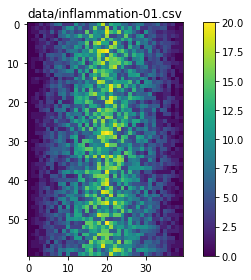

In [17]:
import numpy
import matplotlib
import matplotlib.pyplot

# load the data
filename = 'data/inflammation-01.csv'
data = numpy.loadtxt(fname=filename, delimiter=',')

# Declare plot
fig, ax = matplotlib.pyplot.subplots()
image = ax.imshow(data)
ax.set_title(filename)

# Create colorbar
cbar_kw = {}
cbar = ax.figure.colorbar(image, ax=ax, **cbar_kw)

# plot
fig.tight_layout()
matplotlib.pyplot.show()

This is nice for one file but, how can I do the same operations on many different files?  

We need a way to get a list of all the files in our data directory whose names start with `inflammation-` and end with `.csv`. The `glob` library contains a function, also called `glob`, that finds files and directories whose names match a pattern. We provide those patterns as strings: the character `*` matches zero or more characters, while `?` matches any one character.

In [18]:
import glob
print(glob.glob('data/inflammation*.csv'))

['data\\inflammation-01.csv', 'data\\inflammation-02.csv', 'data\\inflammation-03.csv', 'data\\inflammation-04.csv', 'data\\inflammation-05.csv', 'data\\inflammation-06.csv', 'data\\inflammation-07.csv', 'data\\inflammation-08.csv', 'data\\inflammation-09.csv', 'data\\inflammation-10.csv', 'data\\inflammation-11.csv', 'data\\inflammation-12.csv']


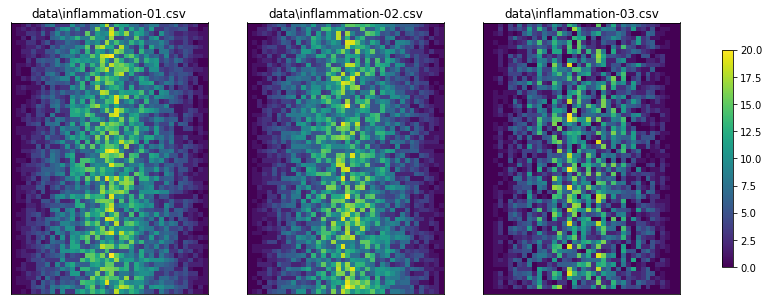

In [19]:
import glob
import numpy
import matplotlib.pyplot as plt

filenames = sorted(glob.glob('data/inflammation*.csv'))
filenames = filenames[0:3]

# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15.0, 5.0))

# Track the images to use for the colorbar
images = []

for i, filename in enumerate(filenames):
    # Load the data
    data = numpy.loadtxt(fname=filename, delimiter=',')
    
    # Plot the heatmap on the corresponding subplot
    img = axes[i].imshow(data, aspect='auto')
    axes[i].set_title(filename)
    axes[i].set_xticks([])  # Remove x-axis ticks for cleaner look
    axes[i].set_yticks([])  # Remove y-axis ticks for cleaner look
    
    images.append(img)

# Create a single colorbar for all subplots
# Use the first image (they all share the same color scale ideally)
fig.colorbar(images[0], ax=axes.ravel().tolist(), shrink=0.8)

plt.show()

`data` has 60 rows and 40 columns. Each *row* represents a *patient* and each *column* holds the inflammation value per *day*. We have 60 patients over 40 days. 

We can see that there are zero values sporadically distributed across all patients and days of the clinical trial, suggesting that there were potential issues with data collection throughout the trial. In addition, we can see that the last patient in the study didn’t have any inflammation flare-ups at all throughout the trial, suggesting that they may not even suffer from arthritis!